# Conditional-method comparison

Analyses a `compare_conditional_methods` experiment: all runs are `lsharp` with
don't-care + reference language, and the only swept dimension is
`conditional_method`. Plotting/summary logic is reused from
`tover.analysis.breakdown`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../")

In [2]:
from tover.analysis.load_data import load_experiment_data, add_symbol_color, clean_data
from tover.analysis.breakdown import (
    plot_runtime_breakdown,
    group_summary,
    method_table,
    style_method_table,
)
from tover.core.synthesis import ConditionalMethod

PATH = "/home/luko/ToVer/monitor-conformence/out/exp-2026-06-09_15-00-21-compare_conditional_methods"

data = load_experiment_data(PATH)
clean_data(data)
add_symbol_color(data)

# Group by conditional method, keeping the enum's order and dropping empties.
groups = {
    m.value: [d for d in data if d["experiment"].get("conditional_method") == m.value]
    for m in ConditionalMethod
}
groups = {k: v for k, v in groups.items() if v}
{k: len(v) for k, v in groups.items()}

Loaded 203 finished, 13 unfinished, 0 not started (216 total) from /home/luko/ToVer/monitor-conformence/out/exp-2026-06-09_15-00-21-compare_conditional_methods


{'rejection': 36,
 'restart': 36,
 'bisection': 36,
 'bisection_advanced': 36,
 'bisection_pt': 36,
 'bisection_advanced_pt': 36}

## Success / runtime per method

How many runs each conditional method completes, and the runtime of the ones
that did. `runs` counts every seed-run, so `success %` is the per-seed-run
reliability — the headline metric for "works best". The runtime stats
(`median`/`total`/`max`) are over the per-benchmark mean runtime (seeds averaged
first, so they aren't inflated by seed count); `benchmarks` is how many distinct
benchmarks the method solved at all.

In [3]:
group_summary(groups).sort_values("success %", ascending=False).reset_index(drop=True)

,group,runs,finished,failed,success %,benchmarks,median (s),total (s),max (s)
0,bisection_advanced_pt,36,33,3,91.7,11,31.44,6245.8,5132.7
1,bisection,36,33,3,91.7,11,14.20,7864.8,6878.7
2,bisection_pt,36,32,4,88.9,11,20.58,5995.8,5102.1
3,rejection,36,30,6,83.3,10,17.18,10788.0,6270.6
4,bisection_advanced,36,30,6,83.3,10,16.06,5164.5,4512.5
5,restart,36,27,9,75.0,9,11.53,1647.4,1404.2


## Runtime per benchmark x method

A focused view of just the runtime column per method (`method_table` with
`metrics=("time",)`), keeping the detailed `benchmark` block (threshold `λ`, MC
size `|S|`/`|T|`). Read across a row to see which method solved a benchmark
fastest (best mean highlighted); each cell is the **mean ± std (n)** over seeds,
or a failure reason where no seed finished. The full set of metrics is in the
next table.

In [4]:
style_method_table(method_table(groups, metrics=("time",)))

## Metrics per benchmark x method (mean ± std over seeds)

The full per-benchmark table: runtime, learning steps, equivalence queries and
learned-monitor size `|M|` for every method. Each benchmark is run under several
`seed`s, so each cell shows the **mean ± std (n)** across the seeds that
succeeded — the std exposes how stable a method is run-to-run, both in its
*values* (time/steps/EQs) and in the *model* it learns (`|M|`). `n/total` flags
cells where only some seeds finished; a failure reason (`∞`, `MO`, `ERR`,
`incorrect`, `—`) appears when none did. The best mean per metric is highlighted.

In [5]:
style_method_table(method_table(groups))

## Inspect a specific run

Once a cell of interest is spotted above, `find_runs` returns the **individual
seed-runs** behind it, with their `json` / `log` paths — using the same
coordinates as `method_table`: `group` is the method (column) and `benchmark` is
either a substring of the row label or the exact `(name, file, h)` index tuple.
Each row is one seed (sorted, failures first), so you can see which seed of an
aggregated `mean ± std (n)` cell failed. `links=True` renders clickable links.

In [6]:
from tover.analysis.breakdown import find_runs

# group=<method column>; benchmark=<substring> or the exact (name, file, h) tuple.
find_runs(groups, group="bisection_advanced", benchmark=("snakes_ladders", "mc_u_nxn.pm", 12), links=False)
find_runs(groups, group="bisection_advanced_pt", benchmark=("snakes_ladders", "mc_u_nxn.pm", 12), links=False)


,group,name,file,h,seed,runtime,learning,smt,reference,product,paynt,eq,counterexample,other,finished,error,json,log,model
0,bisection_advanced_pt,snakes_ladders,mc_u_nxn.pm,12,0,74.81,2.07,57.28,0.38,1.02,12.52,1.45,0.0,0.09,True,None,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/notebooks...
1,bisection_advanced_pt,snakes_ladders,mc_u_nxn.pm,12,1,91.08,3.21,69.26,0.39,1.00,14.76,2.35,0.0,0.11,True,None,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/notebooks...
2,bisection_advanced_pt,snakes_ladders,mc_u_nxn.pm,12,2,13.09,0.62,7.18,0.27,0.25,4.16,0.59,0.0,0.03,True,None,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/notebooks...


## Runtime breakdown

One subplot per benchmark, with one stacked bar per conditional method. Each
subplot has its own linear seconds axis (runtimes aren't comparable across
benchmarks anyway), so the phase composition stays readable. Bars are the
**mean phase times across seeds**; each phase block carries a small ±std whisker
at its top edge (deterministic phases get none, and whiskers are dodged
horizontally within a bar to stay legible). The number above each bar is its
mean total runtime, and `×` marks a method with no result.

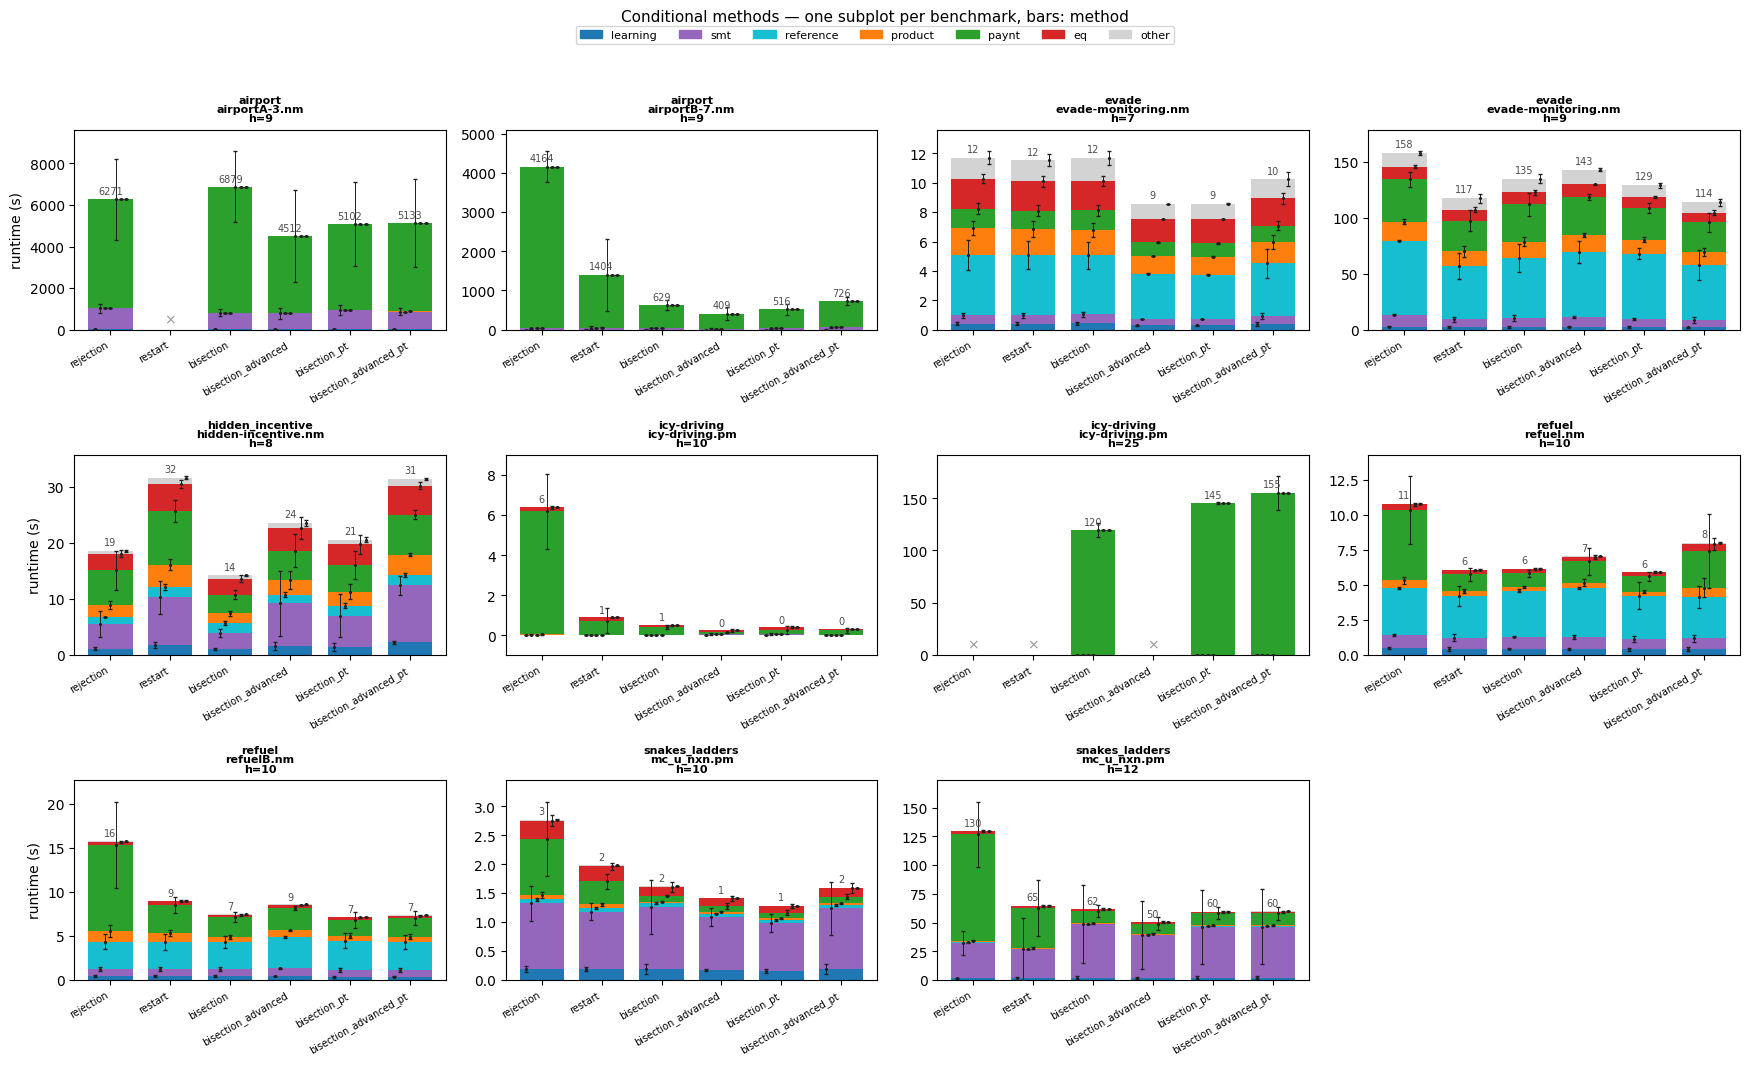

In [7]:
plot_runtime_breakdown(
    groups,
    title="Conditional methods — one subplot per benchmark, bars: method",
)

## PAYNT synthesis over rounds — method comparison

To investigate *why* PAYNT is sometimes slow, and how two methods differ on the
*same* benchmark, the compare helpers overlay several runs in one figure.
`plot_paynt_progress_compare` parses each run's log and plots the four values
PAYNT emits per synthesis call — `family size`, `avg MDP size`, `PAYNT time (s)`
and `MDP iterations` — across the learning rounds; each method gets its own
**colour** while the false-negative / false-positive checks keep distinct
**markers** (○ fn, □ fp), so you can read off which method is more expensive per
round and why. Below it, `plot_round_breakdown_compare` draws the wall-time phase
split per round for the same runs as **grouped stacked bars** (one bar per method
per round, dodged side by side; phase colours shared, **hatch** = method), so the
PAYNT cost can be read against each round's total. Resolve one run per method for
the `(name, file, h)` you want (use `find_runs` to pick coordinates). Long runs
have many rounds, so both helpers (and the single-run `plot_paynt_progress` /
`plot_round_breakdown`) take `round_range=(start, stop)` to zoom into a window of
rounds (0-based, half-open like a slice, either bound optional; `None` shows
every round).

bisection (seed 2) log: /home/luko/ToVer/monitor-conformence/out/exp-2026-06-09_15-00-21-compare_conditional_methods/logs/2026-06-09_15-00-21_airport_897f102a706869a31bf7009ed4341fa3.log
bisection_advanced (seed 2) log: /home/luko/ToVer/monitor-conformence/out/exp-2026-06-09_15-00-21-compare_conditional_methods/logs/2026-06-09_15-00-21_airport_bb8b7e05c1efce2fda40ef63678eda38.log


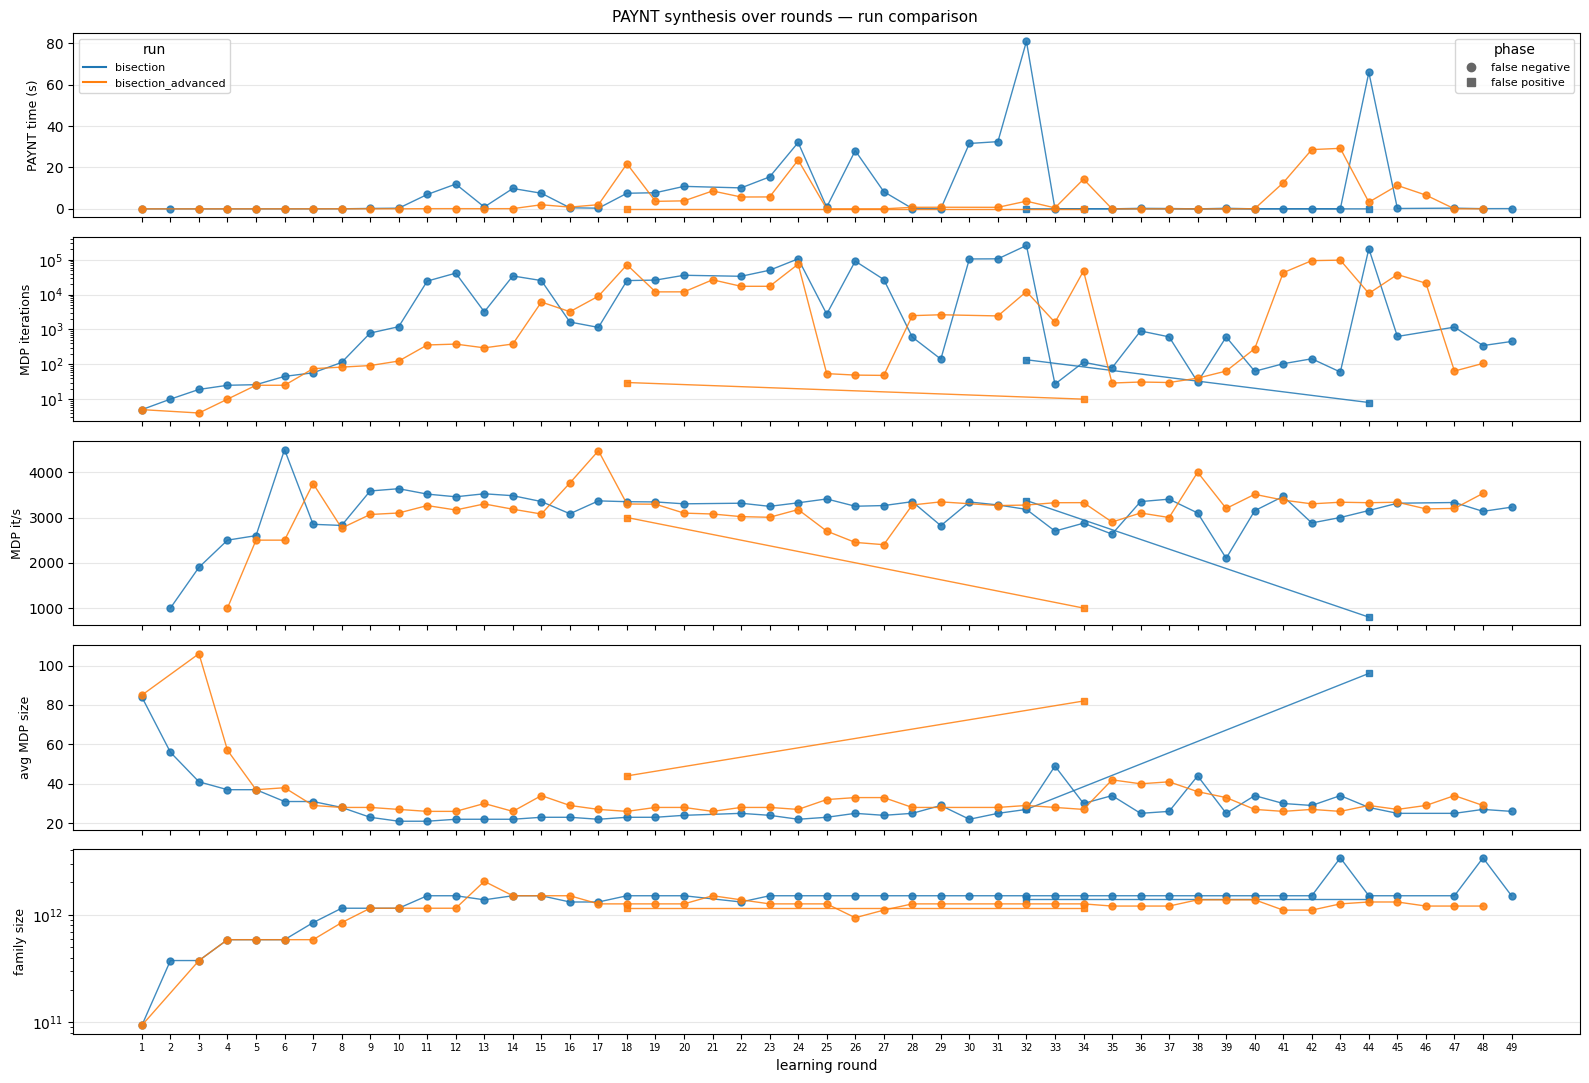

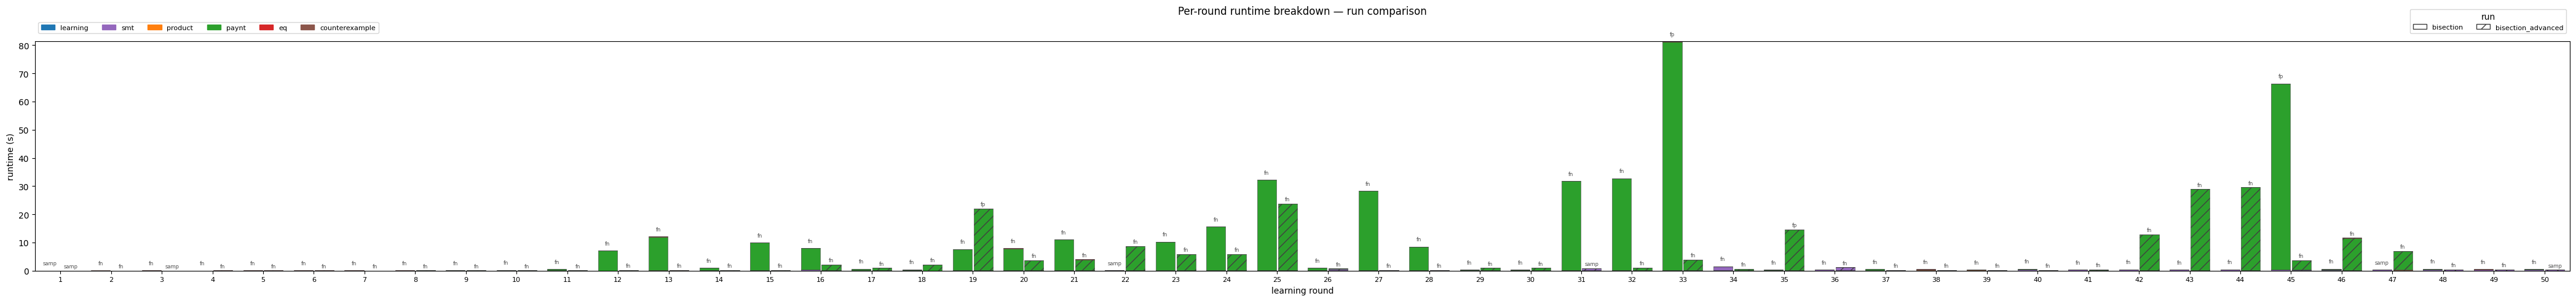

In [8]:
from tover.analysis.breakdown import (
    plot_paynt_progress_compare,
    plot_round_breakdown_compare,
    bench_row,
)

# Compare two methods on the *same* benchmark. For each method pick its
# latest-seed run (with a log) for this (name, file, h), then overlay both in one
# plot. Add/drop methods by editing `methods`.
target = ("airport", "airportA-3.nm", 9)
methods = ["bisection", "bisection_advanced"]

# Long runs have many rounds; `round_range=(start, stop)` zooms into a window
# (0-based, half-open, like a slice — either bound may be None, negatives count
# from the end). Set to None to show every round.
round_range = (0, 50)


def _pick(method):
    return max(
        (d for d in groups[method] if bench_row(d) == target and d.get("log_path")),
        key=lambda d: d["experiment"].get("seed") or 0,
    )


runs = {m: _pick(m) for m in methods}
for run in runs.values():
    print(
        f"{run['experiment']['conditional_method']} (seed {run['experiment'].get('seed')}) log: {run['log_path']}"
    )
plot_paynt_progress_compare(runs, round_range=round_range)    # PAYNT cost per call (colour = method)
plot_round_breakdown_compare(runs, round_range=round_range)   # wall-time phase split per round (hatch = method)

## Pairwise runtime scatter (optional)

Reuses `compare_runtimes` to put one method against another on a log-log plot;
pick any two method keys from `groups`.

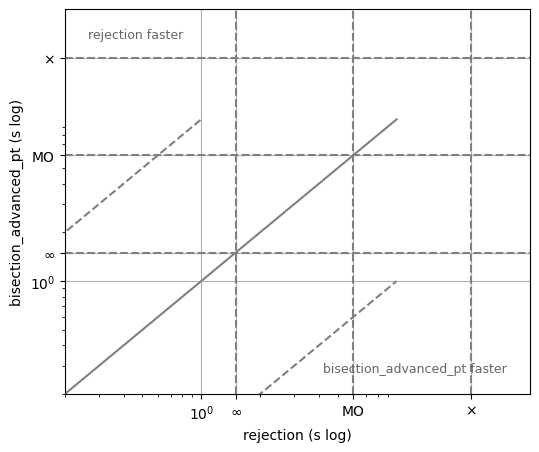

In [9]:
from tover.analysis.plots import compare_runtimes

m1, m2 = "rejection", "bisection_advanced_pt"
compare_runtimes(
    groups[m1],
    groups[m2],
    label1=m1,
    label2=m2,
    figsize=(6, 5),
    plot_kwargs={"markersize": 6, "markeredgewidth": 1.5},
)